In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/game_logs.csv")
print(df.shape)
df.head()

(11658, 29)


,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,...,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS,SEASON
0,22019,1610612743,DEN,Denver Nuggets,21901318,2020-08-14,DEN @ TOR,L,240,109,...,9,32,41,27,9,11,15,15,-8.0,2019-20
1,22019,1610612745,HOU,Houston Rockets,21901315,2020-08-14,HOU vs. PHI,L,240,96,...,1,26,27,25,10,9,17,18,-38.0,2019-20
2,22019,1610612748,MIA,Miami Heat,21901316,2020-08-14,MIA @ IND,L,240,92,...,14,34,48,14,6,5,19,15,-17.0,2019-20
3,22019,1610612746,LAC,LA Clippers,21901317,2020-08-14,LAC vs. OKC,W,265,107,...,12,49,61,23,10,2,20,22,4.0,2019-20
4,22019,1610612761,TOR,Toronto Raptors,21901318,2020-08-14,TOR vs. DEN,W,241,117,...,13,38,51,27,8,5,19,24,8.0,2019-20


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11658 entries, 0 to 11657
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   SEASON_ID          11658 non-null  int64  
 1   TEAM_ID            11658 non-null  int64  
 2   TEAM_ABBREVIATION  11658 non-null  str    
 3   TEAM_NAME          11658 non-null  str    
 4   GAME_ID            11658 non-null  int64  
 5   GAME_DATE          11658 non-null  str    
 6   MATCHUP            11658 non-null  str    
 7   WL                 11658 non-null  str    
 8   MIN                11658 non-null  int64  
 9   PTS                11658 non-null  int64  
 10  FGM                11658 non-null  int64  
 11  FGA                11658 non-null  int64  
 12  FG_PCT             11658 non-null  float64
 13  FG3M               11658 non-null  int64  
 14  FG3A               11658 non-null  int64  
 15  FG3_PCT            11658 non-null  float64
 16  FTM                11658 non-null

In [3]:
df['WL'].value_counts()

WL
L    5829
W    5829
Name: count, dtype: int64

In [4]:
import os

# grab the first file in the pbp folder
pbp_files = os.listdir("../data/raw/pbp")
sample_file = pbp_files[0]

pbp = pd.read_csv(f"../data/raw/pbp/{sample_file}")
print(pbp.shape)
pbp.head(10)

(596, 24)


,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,...,scoreHome,scoreAway,pointsTotal,location,description,actionType,subType,videoAvailable,shotValue,actionId
0,21900001,2,PT12M00.00S,1,0,NaN,0,NaN,NaN,0,...,0.0,0.0,0,NaN,Start of 1st Period (8:04 PM EST),period,start,0,0,1
1,21900001,4,PT12M00.00S,1,1610612761,TOR,201188,Gasol,M. Gasol,0,...,NaN,NaN,0,h,Jump Ball Gasol vs. Favors: Tip to Ball,Jump Ball,NaN,1,0,2
2,21900001,7,PT11M48.00S,1,1610612740,NOP,1628366,Ball,L. Ball,2,...,NaN,NaN,0,v,MISS Ball 11' Driving Floating Jump Shot,Missed Shot,Driving Floating Jump Shot,1,2,3
3,21900001,8,PT11M47.00S,1,1610612740,NOP,202324,Favors,D. Favors,0,...,NaN,NaN,0,v,Favors REBOUND (Off:1 Def:0),Rebound,Unknown,1,0,4
4,21900001,9,PT11M47.00S,1,1610612740,NOP,202324,Favors,D. Favors,0,...,0.0,2.0,2,v,Favors 1' Tip Layup Shot (2 PTS),Made Shot,Tip Layup Shot,1,2,5
5,21900001,10,PT11M29.00S,1,1610612761,TOR,1628384,Anunoby,O. Anunoby,15,...,NaN,NaN,0,h,MISS Anunoby 3' Driving Layup,Missed Shot,Driving Layup Shot,1,2,6
6,21900001,11,PT11M25.00S,1,1610612740,NOP,200755,Redick,J. Redick,0,...,NaN,NaN,0,v,Redick REBOUND (Off:0 Def:1),Rebound,Unknown,1,0,7
7,21900001,12,PT11M16.00S,1,1610612740,NOP,201950,Holiday,J. Holiday,81,...,NaN,NaN,0,v,MISS Holiday 8' Driving Finger Roll Layup,Missed Shot,Driving Finger Roll Layup Shot,1,2,8
8,21900001,13,PT11M15.00S,1,1610612761,TOR,1627832,VanVleet,F. VanVleet,0,...,NaN,NaN,0,h,VanVleet REBOUND (Off:0 Def:1),Rebound,Unknown,1,0,9
9,21900001,14,PT11M11.00S,1,1610612761,TOR,200768,Lowry,K. Lowry,178,...,NaN,NaN,0,h,MISS Lowry 25' 3PT Running Pull-Up Jump Shot,Missed Shot,Running Pull-Up Jump Shot,1,3,10


In [5]:
# SCOREMARGIN tracks the point differential at each moment
# this is the most important column for the ML model
print(pbp.columns.tolist())
print(pbp[['period', 'clock', 'scoreHome', 'scoreAway', 'scoremargin']].dropna().head(20))

['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']


KeyError: "['scoremargin'] not in index"

In [6]:
# V3 gives us scoreHome and scoreAway separately
# we calculate margin ourselves: home score minus away score
pbp_clean = pbp[['period', 'clock', 'scoreHome', 'scoreAway']].copy()

# these columns are empty on non-scoring plays -- forward fill to carry last score
pbp_clean['scoreHome'] = pd.to_numeric(pbp_clean['scoreHome'], errors='coerce').ffill()
pbp_clean['scoreAway'] = pd.to_numeric(pbp_clean['scoreAway'], errors='coerce').ffill()

# calculate margin from home team's perspective
pbp_clean['margin'] = pbp_clean['scoreHome'] - pbp_clean['scoreAway']

print(pbp_clean.dropna().head(20))

    period        clock  scoreHome  scoreAway  margin
0        1  PT12M00.00S        0.0        0.0     0.0
1        1  PT12M00.00S        0.0        0.0     0.0
2        1  PT11M48.00S        0.0        0.0     0.0
3        1  PT11M47.00S        0.0        0.0     0.0
4        1  PT11M47.00S        0.0        2.0    -2.0
5        1  PT11M29.00S        0.0        2.0    -2.0
6        1  PT11M25.00S        0.0        2.0    -2.0
7        1  PT11M16.00S        0.0        2.0    -2.0
8        1  PT11M15.00S        0.0        2.0    -2.0
9        1  PT11M11.00S        0.0        2.0    -2.0
10       1  PT11M08.00S        0.0        2.0    -2.0
11       1  PT11M00.00S        0.0        2.0    -2.0
12       1  PT10M56.00S        0.0        2.0    -2.0
13       1  PT10M54.00S        0.0        2.0    -2.0
14       1  PT10M54.00S        1.0        2.0    -1.0
15       1  PT10M54.00S        1.0        2.0    -1.0
16       1  PT10M51.00S        1.0        2.0    -1.0
17       1  PT10M37.00S     

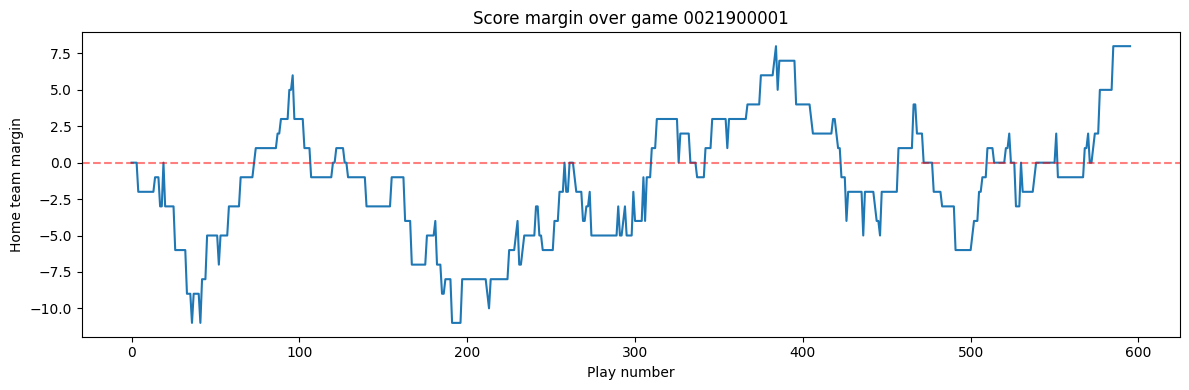

In [7]:
import matplotlib.pyplot as plt

pbp_clean = pbp_clean.dropna().reset_index(drop=True)

plt.figure(figsize=(12, 4))
plt.plot(pbp_clean.index, pbp_clean['margin'])
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.title(f"Score margin over game {sample_file.replace('.csv','')}")
plt.xlabel("Play number")
plt.ylabel("Home team margin")
plt.tight_layout()
plt.show()

In [8]:
# clock looks like "PT11M40.00S" -- we need to convert this to seconds remaining
# lets see what it looks like raw
print(pbp['clock'].head(20))

# and what unique action types exist
print("\nAction types:")
print(pbp['actionType'].value_counts())

0     PT12M00.00S
1     PT12M00.00S
2     PT11M48.00S
3     PT11M47.00S
4     PT11M47.00S
5     PT11M29.00S
6     PT11M25.00S
7     PT11M16.00S
8     PT11M15.00S
9     PT11M11.00S
10    PT11M08.00S
11    PT11M00.00S
12    PT10M56.00S
13    PT10M54.00S
14    PT10M54.00S
15    PT10M54.00S
16    PT10M51.00S
17    PT10M37.00S
18    PT10M27.00S
19    PT10M17.00S
Name: clock, dtype: str

Action types:
actionType
Rebound           129
Missed Shot       120
Made Shot          85
Foul               60
Free Throw         58
Substitution       49
Turnover           36
Timeout            13
period             10
Violation           8
Instant Replay      3
Jump Ball           2
Name: count, dtype: int64


In [9]:
import re

def clock_to_seconds(clock_str):
    # converts "PT11M40.00S" to seconds remaining in the period
    # PT11M40.00S means 11 minutes and 40 seconds remaining
    if pd.isna(clock_str):
        return None
    match = re.match(r'PT(\d+)M([\d.]+)S', str(clock_str))
    if match:
        minutes = int(match.group(1))
        seconds = float(match.group(2))
        return (minutes * 60) + seconds
    return None

# test it
print(clock_to_seconds("PT11M40.00S"))  # should print 700.0
print(clock_to_seconds("PT00M30.00S"))  # should print 30.0
print(clock_to_seconds("PT00M00.00S"))  # should print 0.0

700.0
30.0
0.0


In [10]:
# this is basically what each row will look like going into the ML model
pbp_clean['seconds_remaining_in_period'] = pbp['clock'].apply(clock_to_seconds)

# total seconds remaining in game
# period 1: 3 periods left after + current = (4 - period) * 720 + seconds
pbp_clean['period'] = pbp['period']
pbp_clean['total_seconds_remaining'] = (
    (4 - pbp_clean['period']).clip(lower=0) * 720 
    + pbp_clean['seconds_remaining_in_period'].fillna(0)
)

print(pbp_clean[['period', 'seconds_remaining_in_period', 'total_seconds_remaining', 'margin']].dropna().head(20))

    period  seconds_remaining_in_period  total_seconds_remaining  margin
0        1                        720.0                   2880.0     0.0
1        1                        720.0                   2880.0     0.0
2        1                        708.0                   2868.0     0.0
3        1                        707.0                   2867.0     0.0
4        1                        707.0                   2867.0    -2.0
5        1                        689.0                   2849.0    -2.0
6        1                        685.0                   2845.0    -2.0
7        1                        676.0                   2836.0    -2.0
8        1                        675.0                   2835.0    -2.0
9        1                        671.0                   2831.0    -2.0
10       1                        668.0                   2828.0    -2.0
11       1                        660.0                   2820.0    -2.0
12       1                        656.0            